In [1]:
import numpy as np
import pandas as pd
from plotting_code import apply_style
apply_style("linux")
from approx.approximate import ApprOXimate
analyzer = ApprOXimate()

In [2]:
def compute_charge_balances(analyzer, parsed_formula, alkali_metal, interval, max_range):
    """
    Compute charge balances across a range of alkali metal values
    OPTIMIZED: Uses 'object' return format for structured access
    """
    alkali_metal_amount = parsed_formula.get(alkali_metal, 0)
    if alkali_metal_amount == 0:
        return [], [], f"Error: {alkali_metal} not found in formula"

    values = np.arange(interval, min(alkali_metal_amount, max_range+interval), interval)
    charge_balances = []
    
    for val in values:
        try:
            modified_formula = {**parsed_formula, alkali_metal: val}
            # Use object format for clean access to final_charge
            result = analyzer.charge_balance(modified_formula, return_format='object')
            if result:
                charge_balances.append(result.final_charge)
            else:
                charge_balances.append(np.nan)
        except Exception:
            charge_balances.append(np.nan)
    
    return values, charge_balances

In [3]:
def find_max_na_removed(analyzer, parsed_formula, alkali_metal='Na', interval=0.01, tol=1e-6):
    max_alkali = parsed_formula.get(alkali_metal, 0)
    if max_alkali == 0:
        return max_alkali, np.nan

    n_steps = int(round(max_alkali / interval))
    remaining_values = np.linspace(max_alkali, 0, n_steps + 1)  # guaranteed to include 0 exactly

    last_feasible_remaining = max_alkali

    for remaining in remaining_values:
        modified_formula = {**parsed_formula, alkali_metal: remaining}
        try:
            result = analyzer.charge_balance(modified_formula, return_format='object')
            charge = result.final_charge if result else np.nan
        except Exception:
            charge = np.nan

        if np.isnan(charge) or abs(charge) > tol:
            break
        last_feasible_remaining = remaining

    max_alkali_removed = max_alkali - last_feasible_remaining
    return max_alkali, max_alkali_removed

In [4]:
df_data = pd.read_csv('multi_example_data.csv')
df_data

,Composition,Capacity mAhg-1,Current/C,Voltage Range/V,DOI
0,NaFe0.3Co0.7O2,190,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012
1,NaFe0.4Co0.6O2,150,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012
2,NaFe0.5Co0.5O2,130,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012
3,NaFe0.6Co0.4O2,100,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012
4,NaFe0.7Co0.3O2,80,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012
5,NaFe1/3Co1/3Ni1/3O2,165,0.2,2-4,10.1016/j.elecom.2013.11.015
6,NaLi0.11Ti0.56Ni0.33O2,91,0.2,3.1-3.75,10.1016/j.jpowsour.2016.08.066
7,Na4NiTeO6,111,0.1,3.0-4.5,10.1016/j.jpowsour.2017.06.014
8,NaMg0.15Ti0.7Ni0.15O2,113,0.1,0.2-2.5,10.1016/j.matlet.2020.127950
9,NaTi0.25Fe0.25Co0.25Ni0.25O2,122,12mA/g,2.0-3.9,10.1039/c5ta05769h


In [5]:
from mendeleev import element

In [6]:
q_max_list = []
q_adj_list = []

for idx, row in df_data.iterrows():
        formula = row["Composition"]
        parsed_formula = analyzer.parse_formula(formula)

        mass = 0

        for atom in parsed_formula.keys():
                weighted_mass = element(atom).mass * parsed_formula[atom]
                mass += weighted_mass

        max_na, max_na_removed = find_max_na_removed(analyzer, parsed_formula, alkali_metal="Na", interval=0.01)
        max_na = round(max_na, 2)
        max_na_removed = round(max_na_removed, 2)

        faradays_constant = 96485
        q_max = round((max_na*faradays_constant)/(3.6*mass), 1)
        q_adj = round((max_na_removed*faradays_constant)/(3.6*mass), 1)

        q_max_list.append(q_max)
        q_adj_list.append(q_adj)

df_data["q_max"] = q_max_list
df_data["q_adj"] = q_adj_list

In [7]:
df_data

,Composition,Capacity mAhg-1,Current/C,Voltage Range/V,DOI,q_max,q_adj
0,NaFe0.3Co0.7O2,190,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012,237.2,166.0
1,NaFe0.4Co0.6O2,150,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012,237.8,142.7
2,NaFe0.5Co0.5O2,130,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012,238.5,119.2
3,NaFe0.6Co0.4O2,100,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012,239.2,95.7
4,NaFe0.7Co0.3O2,80,0.2,1.5-4.0,10.1016/j.jpowsour.2019.02.012,239.8,71.9
5,NaFe1/3Co1/3Ni1/3O2,165,0.2,2-4,10.1016/j.elecom.2013.11.015,237.6,156.8
6,NaLi0.11Ti0.56Ni0.33O2,91,0.2,3.1-3.75,10.1016/j.jpowsour.2016.08.066,263.0,176.2
7,Na4NiTeO6,111,0.1,3.0-4.5,10.1016/j.jpowsour.2017.06.014,286.5,143.2
8,NaMg0.15Ti0.7Ni0.15O2,113,0.1,0.2-2.5,10.1016/j.matlet.2020.127950,265.5,185.9
9,NaTi0.25Fe0.25Co0.25Ni0.25O2,122,12mA/g,2.0-3.9,10.1039/c5ta05769h,242.9,182.2


Q_max: MAE=125.0 mAh/g, R2=-21.95
Q_adj: MAE=54.4 mAh/g, R2=-5.60


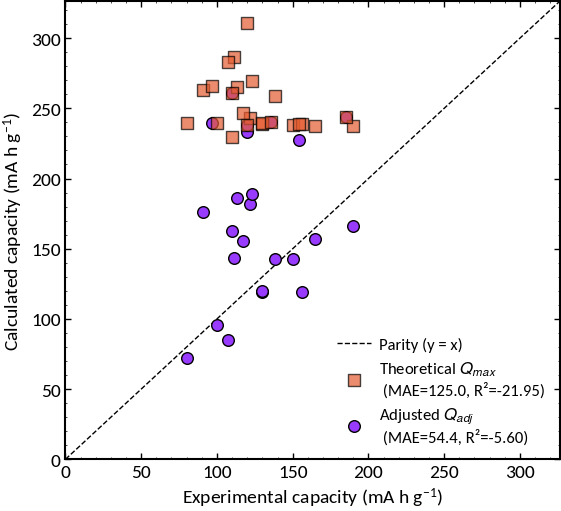

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

exp = df_data["Capacity mAhg-1"]
q_max = df_data["q_max"]
q_adj = df_data["q_adj"]

mae_max, r2_max = mean_absolute_error(exp, q_max), r2_score(exp, q_max)
mae_adj, r2_adj = mean_absolute_error(exp, q_adj), r2_score(exp, q_adj)

print(f"Q_max: MAE={mae_max:.1f} mAh/g, R2={r2_max:.2f}")
print(f"Q_adj: MAE={mae_adj:.1f} mAh/g, R2={r2_adj:.2f}")

fig, ax = plt.subplots(figsize=(6, 5.5))

lims = [0, max(exp.max(), q_max.max(), q_adj.max()) * 1.05]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1, zorder=1, label="Parity (y = x)")

ax.scatter(exp, q_max, color="#e55c30", edgecolor="k", s=70, alpha=0.7, zorder=3, marker="s",
           label=f"Theoretical $Q_{{max}}$ \n (MAE={mae_max:.1f}, R²={r2_max:.2f})")

ax.scatter(exp, q_adj, color="#993bff", edgecolor="k", s=70, zorder=2,
           label=f"Adjusted $Q_{{adj}}$ \n (MAE={mae_adj:.1f}, R²={r2_adj:.2f})")

ax.set_xlabel("Experimental capacity (mA h g$^{-1}$)")
ax.set_ylabel("Calculated capacity (mA h g$^{-1}$)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.savefig("outputs/parity_qmax_vs_qadj.png", dpi=300)
plt.show()

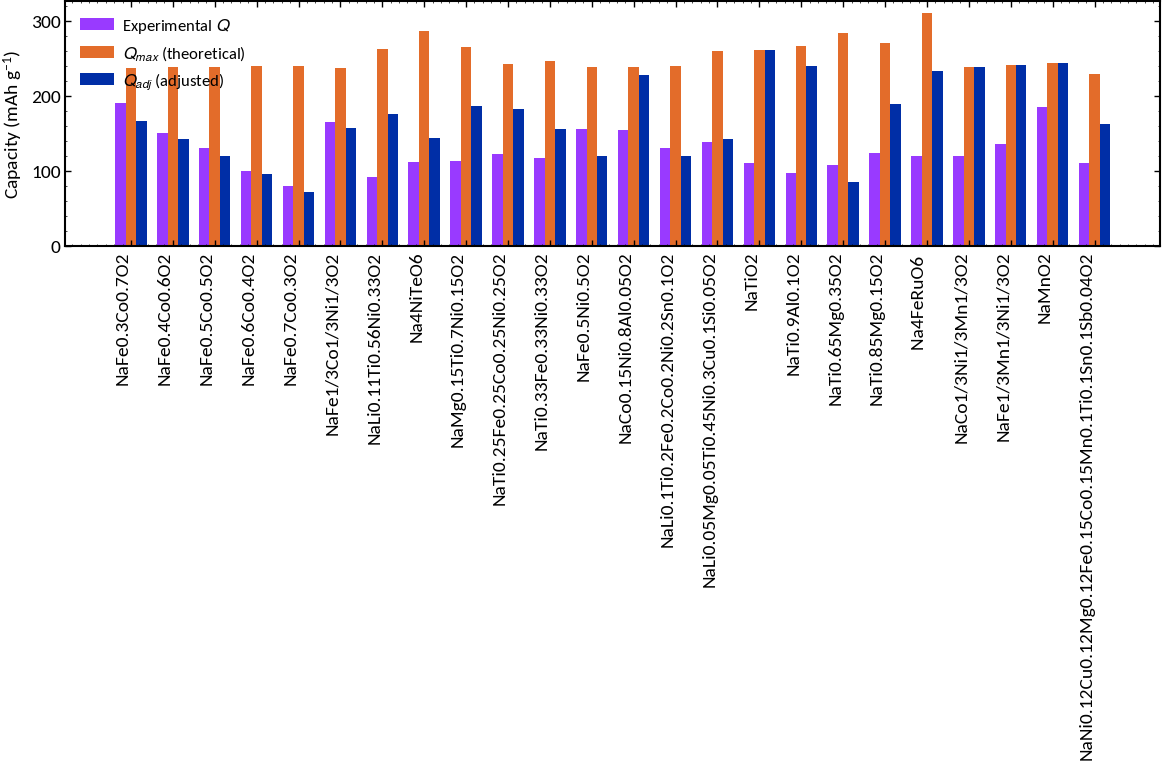

In [9]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(df_data))
width = 0.25

ax.bar(x - width, df_data["Capacity mAhg-1"], width, label="Experimental $Q$", color="#993AFF")
ax.bar(x, df_data["q_max"], width, label="$Q_{max}$ (theoretical)", color="#E36C2A")
ax.bar(x + width, df_data["q_adj"], width, label="$Q_{adj}$ (adjusted)", color="#002ea6")

ax.set_xticks(x)
ax.set_xticklabels(df_data["Composition"], rotation=90, ha="right")
ax.set_ylabel("Capacity (mAh g$^{-1}$)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("outputs/bar_comparison.png", dpi=300)
plt.show()